# Phasing

Wrote table: haplotype_skew_summary_noncyclo_individual.tsv
Wrote figure: haplotype_skew_plot_noncyclo_jitter_individual.pdf


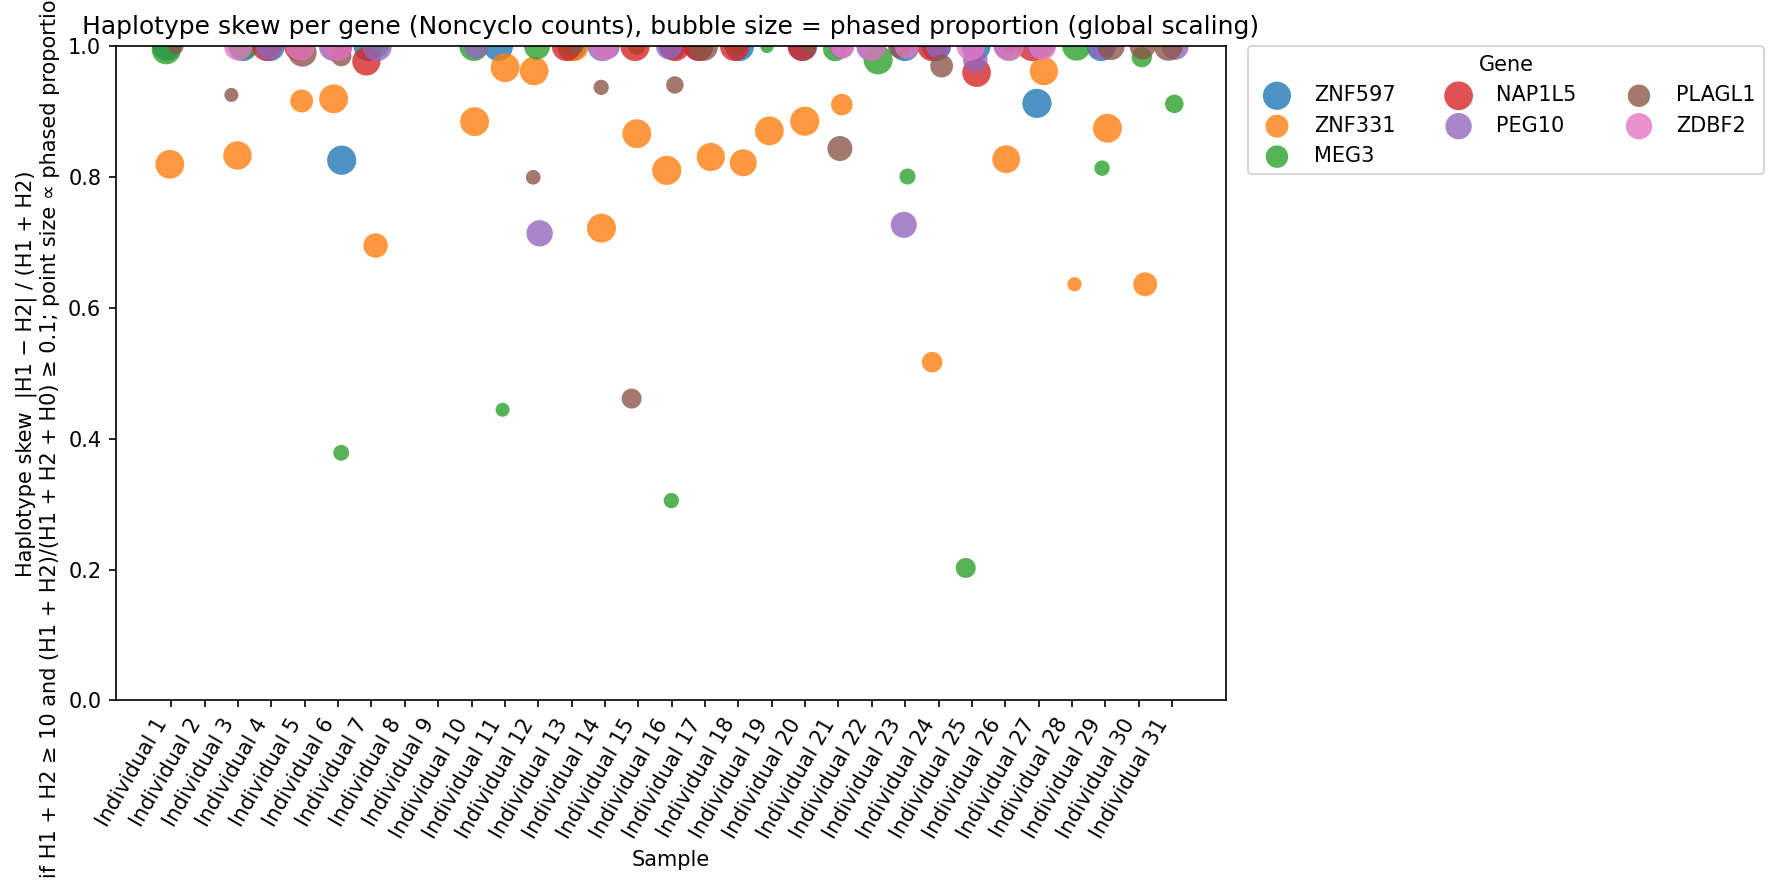

In [1]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

################
#  Inputs
################
FILE = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/Noncyclo_Allelic_Imbalance_gen_full_test_stat_and_z_scored_data.tsv.gz"
GENES_OF_INTEREST = ["ZNF597", "ZNF331", "MEG3", "NAP1L5", "PEG10", "PLAGL1", "ZDBF2", "DLK1"]
OUT_TABLE = "haplotype_skew_summary_noncyclo_individual.tsv"
OUT_FIG   = "haplotype_skew_plot_noncyclo_jitter_individual.pdf"
MIN_TOTAL = 10         # require H1 + H2 >= 10 to compute skew
PHASED_PROP_MIN = 0.1  # require (H1 + H2)/(H1 + H2 + H0) >= 0.1 to compute skew

df = pd.read_csv(FILE, sep="\t", compression='gzip')

################
# Rename samples
################
sample_rename = {
    "UDN687128": "Individual 1",
    "UDN215640": "Individual 2",
    "UDN633333": "Individual 3",
    "UDN318336": "Individual 4",
    "UDN052264": "Individual 5",
    "UDN212054": "Individual 6",
    "UDN355246": "Individual 7",
    "UDN860070": "Individual 8",
    "UDN353099": "Individual 9",
    "UDN305049": "Individual 10",
    "UDN310876": "Individual 11",
    "BCH_1199-01": "Individual 12",
    "BCH_1877-01": "Individual 13",
    "BCH_310-01": "Individual 14",
    "UDN121217": "Individual 15",
    "UDN374570": "Individual 16",
    "UDN827597": "Individual 17",
    "UDN966087": "Individual 18",
    "UDN204349": "Individual 19",
    "UDN359892": "Individual 20",
    "UDN262407": "Individual 21",
    "UDN924176": "Individual 22",
    "UDN666440": "Individual 23",
    "UDN178694": "Individual 24",
    "BCH_1986-01": "Individual 25",
    "BCH_0252-01": "Individual 26",
    "BCH_2275-01": "Individual 27",
    "BCH_2401-01": "Individual 28",
    "BCH_2410-01": "Individual 29",
    "BCH_2443-01": "Individual 30",
    "UDN010451": "Individual 31"
}

df["Sample"] = df["Sample"].replace(sample_rename)

################
# Order samples 
################
df["Sample_num"] = df["Sample"].str.extract(r"Individual (\d+)", expand=False).astype(float)
sample_order = df.sort_values("Sample_num")["Sample"].unique()

# exact columns per your file
sample_col = "Sample"
gene_col   = "associated_gene"
h0_col     = "H0_noncyclo_count"
h1_col     = "H1_noncyclo_count"
h2_col     = "H2_noncyclo_count"

# keep original sample order
#sample_order = pd.unique(df[sample_col])

################
#  Filter to genes of interest
################
df = df[df[gene_col].isin(GENES_OF_INTEREST)].copy()

################
# Compute haplotype skew only if thresholds are met
################

den = df[h1_col] + df[h2_col]
num = (df[h1_col] - df[h2_col]).abs()
phased_proportion = den / (den + df[h0_col])

df["haplotype_skew"] = np.where(
    (den >= MIN_TOTAL) & (phased_proportion >= PHASED_PROP_MIN),
    num / den,
    np.nan
)
df["phased_proportion"] = phased_proportion  # for point sizing

################
# Prepare pivots for plotting
################
tidy = df.rename(columns={
    sample_col: "Sample",
    gene_col: "Gene",
    h0_col: "H0_noncyclo_count",
    h1_col: "H1_noncyclo_count",
    h2_col: "H2_noncyclo_count"
})[["Sample", "Gene", "H0_noncyclo_count", "H1_noncyclo_count", "H2_noncyclo_count", "haplotype_skew", "phased_proportion"]]

tidy.sort_values(["Sample", "Gene"]).to_csv(OUT_TABLE, sep="\t", index=False)
print(f"Wrote table: {OUT_TABLE}")

pivot_skew = (
    tidy.pivot(index="Sample", columns="Gene", values="haplotype_skew")
        .reindex(sample_order)
)
pivot_phase = (
    tidy.pivot(index="Sample", columns="Gene", values="phased_proportion")
        .reindex(sample_order)
)

################
#  Global min/max for phased_proportion across all plotted points 
################

valid_phase = (
    tidy.loc[tidy["haplotype_skew"].notna(), "phased_proportion"]
      .dropna()
      .astype(float)
)
if valid_phase.empty:
    G_MIN, G_MAX = 0.0, 0.0  # fallback; loop will use mid-size
else:
    G_MIN, G_MAX = valid_phase.min(), valid_phase.max()

################
# plot points. Size ~ global phased_proportion
################
plt.figure(figsize=(12, 6), dpi=150)

# matplotlib 's' is marker *area* in points^2
S_MIN, S_MAX = 36, 196
x_positions = np.arange(len(pivot_skew.index))  # numeric x for samples

for gene in [g for g in GENES_OF_INTEREST if (g in pivot_skew.columns and g in pivot_phase.columns)]:
    y = pivot_skew[gene]
    p = pivot_phase[gene]

    mask = y.notna() & p.notna()
    if not mask.any():
        continue

    phase_vals = p[mask].astype(float)

    # GLOBAL scaling: same mapping for every gene
    if G_MIN == G_MAX:
        sizes = np.full(mask.sum(), (S_MIN + S_MAX) / 2.0)
    else:
        sizes = np.interp(phase_vals, (G_MIN, G_MAX), (S_MIN, S_MAX))

    # jittered x positions
    jitter = np.random.uniform(-0.2, 0.2, size=mask.sum())
    x_jittered = x_positions[mask] + jitter

    plt.scatter(
        x_jittered, y[mask], s=sizes,
        label=gene, alpha=0.8, edgecolors="none", linewidth=0.4
    )

plt.ylim(0, 1)
plt.ylabel(
    f"Haplotype skew  |H1 − H2| / (H1 + H2)\n"
    f"(only if H1 + H2 ≥ {MIN_TOTAL} and (H1 + H2)/(H1 + H2 + H0) ≥ {PHASED_PROP_MIN}; "
    f"point size ∝ phased proportion, globally scaled)"
)
plt.xlabel("Sample")
plt.title("Haplotype skew per gene (Noncyclo counts), bubble size = phased proportion (global scaling)")
plt.xticks(x_positions, pivot_skew.index, rotation=60, ha="right")

# Put legend outside on the right, 3 columns
ax = plt.gca()
ax.legend(title="Gene", ncols=3, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.savefig(OUT_FIG, bbox_inches="tight")
print(f"Wrote figure: {OUT_FIG}")


In [10]:
df

,associated_gene,Sample,cyclo_count,noncyclo_count,Cyclo_TPM,Noncyclo_TPM,total_cyclo,total_noncyclo,H0_cyclo_count,H1_cyclo_count,...,Noncyclo_TPM_Rank,Cyclo_TPM_Median,Noncyclo_TPM_Median,Cyclo_TPM_Mean,Noncyclo_TPM_Mean,NoncycloHaplotypeDifference,test_statistic,z_score_of_test_stat,haplotype_skew,phased_proportion
129301,DLK1,Patient 26,0,0,0.000000,0.000000,6655126,4374709,0,0,...,22.5,0.000000,0.000000,0.253004,0.215243,NaN,0.000000,0.000000,NaN,NaN
129302,DLK1,Patient 12,2,1,0.299390,0.231353,6680255,4322405,0,2,...,9.0,0.000000,0.000000,0.253004,0.215243,1.0,0.000000,0.000000,NaN,1.000000
129303,DLK1,Patient 13,0,0,0.000000,0.000000,4960980,4963482,0,0,...,22.5,0.000000,0.000000,0.253004,0.215243,NaN,0.000000,0.000000,NaN,NaN
129304,DLK1,Patient 25,0,1,0.000000,0.177113,5700954,5646105,0,0,...,13.0,0.000000,0.000000,0.253004,0.215243,1.0,0.000000,0.000000,NaN,1.000000
129305,DLK1,Patient 27,0,5,0.000000,0.802960,5299150,6226963,0,0,...,3.0,0.000000,0.000000,0.253004,0.215243,-1.0,0.000000,0.000000,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613423,ZNF597,Patient 1,131,30,20.116856,4.562202,6511952,6575772,6,0,...,10.0,13.201646,4.141732,14.913099,4.496648,-1.0,23.837581,0.750188,1.0,0.966667
613424,ZNF597,Patient 17,67,40,12.869724,7.071252,5206017,5656707,0,67,...,4.0,13.201646,4.141732,14.913099,4.496648,1.0,28.128531,1.132014,1.0,0.975000
613425,ZNF597,Patient 8,76,19,11.607386,3.119137,6547555,6091428,76,0,...,26.0,13.201646,4.141732,14.913099,4.496648,NaN,0.000000,-1.467500,NaN,0.000000
613426,ZNF597,Patient 22,42,29,7.138433,5.116962,5883644,5667425,1,3,...,8.0,13.201646,4.141732,14.913099,4.496648,-1.0,23.837581,0.750188,1.0,1.000000


# Hierarchical clustering

In [18]:
def filter_based_on_counts(df, count_threshold=10, group_col='Isoform'):
    """
    Filter isoforms based on count thresholds.
    
    Parameters:
    - df (pd.DataFrame): The input long-format DataFrame.
    - count_threshold (int): The threshold for filtering counts.
    - group_col (str): The column to group by (e.g., 'Isoform', 'Isoform_PBid').
    
    Returns:
    - pd.DataFrame: Filtered DataFrame with only the groups meeting the count threshold.
    """
    # Determine isoforms/groups to keep based on the threshold
    isoforms_to_keep = df.groupby(group_col).apply(
        lambda group: any(group['cyclo_count'] >= count_threshold) or any(group['noncyclo_count'] >= count_threshold)
    )
    isoforms_to_keep = isoforms_to_keep[isoforms_to_keep].index.tolist()

    # Filter the DataFrame to include only the isoforms/groups to keep
    return df[df[group_col].isin(isoforms_to_keep)]

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from matplotlib.lines import Line2D

def process_and_plot_dendrogram_log(
    df,
    output_pdf="hc_dendrogram.pdf",
    grouping_col="associated_gene",
    linkage_method="average",     # e.g., "average", "complete", "single", "ward"
    metric="euclidean",           # e.g., "euclidean", "cosine", "correlation", etc.
    standardize=True,             # z-score features (recommended)
    n_clusters=None,              # set an integer to cut the tree into k clusters
    distance_threshold=None,      # or cut at a distance (incompatible with n_clusters)
    orientation="left",           # "left" puts samples on the y-axis (good for many samples)
    label_fontsize=12
):
    """
    Performs hierarchical clustering on transcript expression data and generates a dendrogram.

    Parameters:
    - df (pd.DataFrame): Input with columns:
        - 'Sample' (str): identifier for each sample.
        - grouping_col (str): gene/isoform column (e.g., 'associated_gene' or 'Isoform').
        - 'Cyclo_TPM' (float): TPM values for CHX-treated samples.
        - 'Noncyclo_TPM' (float): TPM values for untreated samples.
    - output_pdf (str): Where to save the dendrogram PDF.
    - grouping_col (str): Column to group TPM values by (genes or isoforms).
    - linkage_method (str): Linkage method for clustering.
    - metric (str): Distance metric for pairwise distances.
    - standardize (bool): Z-score features across samples before clustering.
    - n_clusters (int or None): If set, assigns cluster IDs by cutting the tree into k clusters.
    - distance_threshold (float or None): If set, assigns cluster IDs by cutting at a distance.
      (Do not set together with n_clusters.)
    - orientation (str): "left", "right", "top", or "bottom".
    - label_fontsize (int): Font size for sample labels on the dendrogram.

    Returns:
    - pd.DataFrame with:
        - 'Sample' (str)
        - 'Condition' (Cyclo/Noncyclo)
        - 'Order' (int): plotting order from the dendrogram
        - 'Cluster' (int, optional): present if n_clusters or distance_threshold is provided

    Notes:
    - Mirrors the preprocessing in process_and_plot_pca():
      filters by count threshold (via filter_based_on_counts),
      aggregates TPM by Sample x grouping_col, duplicates into Cyclo/Noncyclo,
      pivots to samples x features, removes all-zero rows, optionally standardizes,
      then performs hierarchical clustering and plots the dendrogram.
    """

    # 1) Filter (uses your existing helper)
    df_filtered = filter_based_on_counts(df, count_threshold=10, group_col=grouping_col)

    # 2) Group by Sample and grouping_col and sum TPM values
    grouped_df = (
        df_filtered.groupby(["Sample", grouping_col])[["Cyclo_TPM", "Noncyclo_TPM"]]
        .sum()
        .reset_index()
    )

    # 3) Build Cyclo / Noncyclo long tables
    cyclo_df = grouped_df[["Sample", grouping_col, "Cyclo_TPM"]].copy()
    noncyclo_df = grouped_df[["Sample", grouping_col, "Noncyclo_TPM"]].copy()
    cyclo_df.columns = ["Sample", grouping_col, "TPM"]
    noncyclo_df.columns = ["Sample", grouping_col, "TPM"]
    cyclo_df["Sample"] = cyclo_df["Sample"] + "_Cyclo"
    noncyclo_df["Sample"] = noncyclo_df["Sample"] + "_Noncyclo"

    final_df = pd.concat([cyclo_df, noncyclo_df], ignore_index=True)

    # 4) Pivot to samples x features, fill NAs with 0, drop all-zero rows
    pivot_df = final_df.pivot(index="Sample", columns=grouping_col, values="TPM").fillna(0)
    pivot_df = pivot_df.loc[pivot_df.any(axis=1)]

    pivot_df = pivot_df.apply(np.log1p)  # log(1 + TPM) #THIS LINE IS CRITICAL

    if pivot_df.shape[0] < 2:
        raise ValueError("Need at least two samples (rows) after filtering/pivoting to build a dendrogram.")

    # 5) Optional standardization (feature-wise z-score)
    X = pivot_df.values
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # 6) Pairwise distances and linkage
    dists = pdist(X, metric=metric)
    Z = linkage(dists, method=linkage_method)

    # 7) Plot dendrogram
    labels = pivot_df.index.tolist()
    n_samples = len(labels)
    # Size heuristic: taller figure for more samples if horizontal dendrogram (left/right)
    if orientation in ("left", "right"):
        figsize = (8, max(2, 0.25 * n_samples + 2))
    else:
        figsize = (max(6, 0.25 * n_samples + 2), 6)

    fig, ax = plt.subplots(figsize=figsize)
    dendro = dendrogram(
        Z,
        labels=labels,
        orientation=orientation,
        leaf_font_size=label_fontsize,
        above_threshold_color="gray",  # keep link colors neutral
        ax=ax
    )

    ax.set_title("Hierarchical Clustering Dendrogram")
    # Axis label depends on orientation
    if orientation in ("left", "right"):
        ax.set_xlabel("Distance")
    else:
        ax.set_ylabel("Distance")

    # 8) Color leaf labels by condition
    color_mapping = {"Cyclo": "red", "Noncyclo": "blue"}
    # Tick labels are on the axis perpendicular to the dendrogram leaves
    ticklabels = ax.get_yticklabels() if orientation in ("left", "right") else ax.get_xticklabels()
    for tl in ticklabels:
        s = tl.get_text()
        cond = "Cyclo" if s.endswith("_Cyclo") else "Noncyclo"
        tl.set_color(color_mapping.get(cond, "black"))

    # Legend for conditions
    legend_elems = [
        Line2D([0], [0], marker='o', linestyle='', label='Cyclo', markerfacecolor=color_mapping["Cyclo"]),
        Line2D([0], [0], marker='o', linestyle='', label='Noncyclo', markerfacecolor=color_mapping["Noncyclo"]),
    ]
    ax.legend(handles=legend_elems, title="Condition", loc="best")

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close(fig)

    # 9) Build result DataFrame (order matches dendrogram leaf order)
    ordered_labels = dendro["ivl"]
    order_map = {lab: i for i, lab in enumerate(ordered_labels)}
    out = pd.DataFrame({
        "Sample": ordered_labels,
        "Condition": ["Cyclo" if s.endswith("_Cyclo") else "Noncyclo" for s in ordered_labels],
        "Order": [order_map[s] for s in ordered_labels],
    })

    # Optional, assign clusters
    if (n_clusters is not None) and (distance_threshold is not None):
        raise ValueError("Provide either n_clusters or distance_threshold, not both.")
    if n_clusters is not None:
        clusters = fcluster(Z, t=n_clusters, criterion="maxclust")
        # clusters are in the original row order; map to labels
        sample_to_cluster = {lab: clusters[i] for i, lab in enumerate(labels)}
        out["Cluster"] = [sample_to_cluster[s] for s in ordered_labels]
    elif distance_threshold is not None:
        clusters = fcluster(Z, t=distance_threshold, criterion="distance")
        sample_to_cluster = {lab: clusters[i] for i, lab in enumerate(labels)}
        out["Cluster"] = [sample_to_cluster[s] for s in ordered_labels]

    return out


In [20]:
# Same df you use for PCA:
df = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Command_line/9.7.25_iso_allele/Output/intermediate/long_format_annotated.tsv.gz", 
                 sep='\t',           # Tab-separated
                 compression='gzip') # Specify the compression type

In [21]:
# ---------- rename samples (preserve suffixes like _cyclo) ----------
sample_rename = {
    "UDN687128": "Individual 1",
    "UDN215640": "Individual 2",
    "UDN633333": "Individual 3",
    "UDN318336": "Individual 4",
    "UDN052264": "Individual 5",
    "UDN212054": "Individual 6",
    "UDN355246": "Individual 7",
    "UDN860070": "Individual 8",
    "UDN353099": "Individual 9",
    "UDN305049": "Individual 10",
    "UDN310876": "Individual 11",
    "BCH_1199-01": "Individual 12",
    "BCH_1877-01": "Individual 13",
    "BCH_310-01": "Individual 14",
    "UDN121217": "Individual 15",
    "UDN374570": "Individual 16",
    "UDN827597": "Individual 17",
    "UDN966087": "Individual 18",
    "UDN204349": "Individual 19",
    "UDN359892": "Individual 20",
    "UDN262407": "Individual 21",
    "UDN924176": "Individual 22",
    "UDN666440": "Individual 23",
    "UDN178694": "Individual 24",
    "BCH_1986-01": "Individual 25",
    "BCH_0252-01": "Individual 26",
    "BCH_2275-01": "Individual 27",
    "BCH_2401-01": "Individual 28",
    "BCH_2410-01": "Individual 29",
    "BCH_2443-01": "Individual 30",
    "UDN010451": "Individual 31"
}

def rename_sample_with_suffix(name):
    """Convert e.g. 'UDN687128_cyclo' -> 'Individual 1_cyclo'."""
    for old, new in sample_rename.items():
        if name.startswith(old):
            return name.replace(old, new, 1)
    return name  # unchanged if not in map

df["Sample"] = df["Sample"].apply(rename_sample_with_suffix)


In [22]:
dendro_df = process_and_plot_dendrogram_log(
    df,
    output_pdf="samples_hc_dendrogram_gene_ward_euclidean_log_renamed_individual.pdf",
    grouping_col="associated_gene",
    linkage_method="ward",
    metric="euclidean",
    standardize=False,
    #n_clusters=2,          # optional: assign cluster IDs
    orientation="left"
)

/tmp/ipykernel_53895/2215968530.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  isoforms_to_keep = df.groupby(group_col).apply(


# SRSF6 exonic proportion

In [1]:
import os
import sys
import gzip
import pandas as pd
import numpy as np
import pysam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
def process_pileup(df, reference_fasta, chromosome, position, output_file):
    """
    Processes pileup data from BAM files for a specific genomic position, extracting read depth, 
    nucleotide composition, and base qualities.

    Parameters:
    - df (pd.DataFrame): Input DataFrame containing sample and BAM file information. 
                         Expected columns: ['sample', 'patient', 'cyclo', 'bam_file']
    - reference_fasta (str): Path to the reference FASTA file, used to retrieve the reference base.
    - chromosome (str): Chromosome name (e.g., 'chr1', '2', 'X') for the pileup analysis.
    - position (int): genomic position at which pileup data is collected.
    - output_file (str): Path to save the results as a compressed tsv (gzip format).

    Returns:
    - None: Saves a compressed tsv file with columns:
        - 'Source': Unique identifier combining 'sample', 'patient', and 'cyclo'.
        - 'Chromosome': Chromosome name.
        - 'Position': Genomic position.
        - 'Reference_Base': Reference nucleotide at this position.
        - 'Original_Read_Depth': Total number of reads covering the position.
        - 'Exon_Read_Depth': Number of reads containing an exonic nucleotide (A, C, T, or G).
        - 'Exonic_Proportion': Proportion of exonic reads (Exon_Read_Depth / Original_Read_Depth).
        - 'Read_Bases': String of bases observed at this position.
        - 'Base_Qualities': ASCII-encoded Phred quality scores.

    Notes:
    - Uses `pysam.AlignmentFile.pileup()` to extract pileup data from BAM files.
    - Reference bases are obtained from the provided FASTA file.
    - Reads that contain deletions or are soft-clipped at this position are ignored.
    - Assumes that **A, C, T, G** bases represent exonic reads.
    - If a BAM file does not exist, an "N/A" row is added to the results.
    - Errors encountered during processing are logged in the output file.
    """

    #unique_bams = df.drop_duplicates(subset=['bam_file'])[['sample', 'individual', 'condition', 'bam_file']]
    unique_bams = df.drop_duplicates(subset=['individual', 'condition'])[['sample', 'individual', 'condition', 'bam_file']]

    
    results = [["Source", "Chromosome", "Position", "Reference_Base", "Original_Read_Depth", "Exon_Read_Depth", "Exonic_Proportion", "Read_Bases", "Base_Qualities"]]
    
    for _, row in unique_bams.iterrows():
        source = f"{row['individual']}_{row['condition']}"
        bam_file = row['bam_file']
        print(f"Processing BAM file: {bam_file} from source: {source}")
        
        if pd.notna(bam_file) and os.path.exists(bam_file):
            try:
                samfile = pysam.AlignmentFile(bam_file, "rb")
                pileup_data = []
                
                for pileupcolumn in samfile.pileup(chromosome, position - 1, position, truncate=True, fasta=pysam.FastaFile(reference_fasta)):
                    ref_base = pileupcolumn.reference_pos
                    read_depth = pileupcolumn.n
                    read_bases = ''.join([pileupread.alignment.query_sequence[pileupread.query_position] if pileupread.query_position is not None else '' for pileupread in pileupcolumn.pileups])
                    base_qualities = ''.join([chr(pileupread.alignment.query_qualities[pileupread.query_position] + 33) if pileupread.query_position is not None else '' for pileupread in pileupcolumn.pileups])
                    
                    exon_read_count = read_bases.count('A') + read_bases.count('C') + read_bases.count('T') + read_bases.count('G')
                    exonic_proportion = exon_read_count / read_depth if read_depth > 0 else 0
                    
                    pileup_data.append([source, chromosome, position, ref_base, read_depth, exon_read_count, round(exonic_proportion, 2), read_bases, base_qualities])
                
                samfile.close()
                results.extend(pileup_data if pileup_data else [[source, chromosome, position, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"]])
            except Exception as e:
                results.append([source, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", str(e)])
        else:
            print(f"{bam_file} not found")
            results.append([source, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"])
    
        
    df_output = pd.DataFrame(results[1:], columns=results[0])
    df_output.to_csv(output_file, index=False, compression = "gzip", sep="\t")
    print(f"Processing complete. Results saved to {output_file}")

Analzying SRSF6 cassette exon inclusion
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN633333_untreated_non-cyclo_PS00344.tagged.bam from source: Individual 3_noncyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN633333_treated_cyclo_PS00345.tagged.bam from source: Individual 3_cyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN212054_untreated_non-cyclo_PS00362.tagged.bam from source: Individual 6_noncyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN212054_treated_cyclo_PS00363.tagged.bam from source: Individual 6_cyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/tag/UDN215640_untreated_non-cyclo_PS00364.tagged.bam from source: Individual 2_noncyclo
Processing BAM file: /mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/result

/tmp/ipykernel_52950/899332733.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x="Source", y="Exonic_Proportion", edgecolor="black", palette=colors)


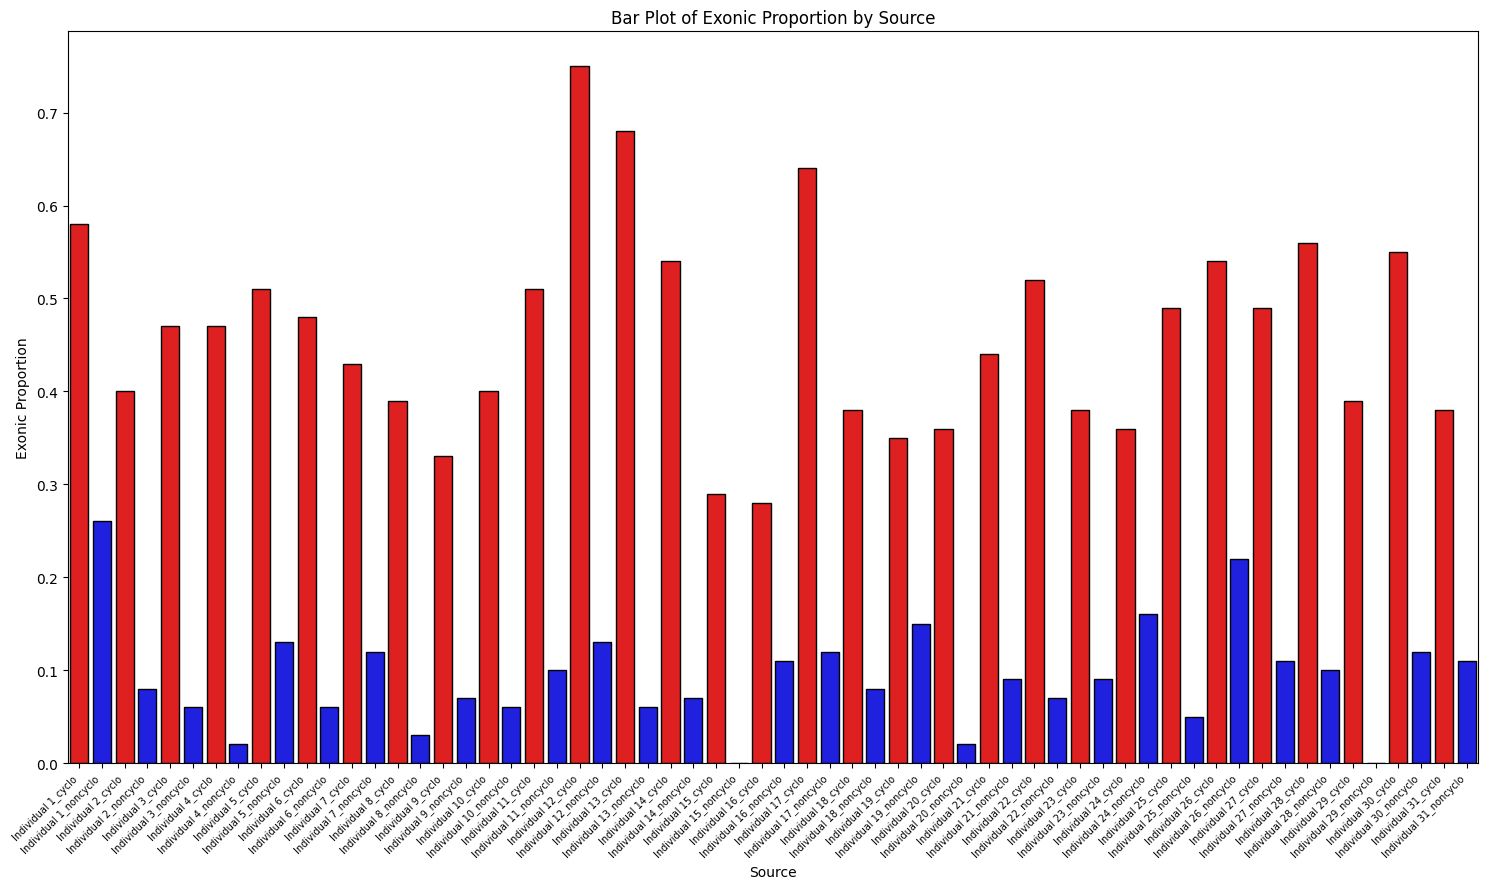

In [3]:
print("Analzying SRSF6 cassette exon inclusion", flush=True)

sample_info = pd.read_csv("/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Add_genetic_and_haplotype/3.28.25/Sample_info.tsv", sep="\t")
reference_fasta_path = "/gscratch/stergachislab/assemblies/simple-names/hg38.fa"

# ---------- rename samples ----------
sample_rename = {
    "UDN687128": "Individual 1",
    "UDN215640": "Individual 2",
    "UDN633333": "Individual 3",
    "UDN318336": "Individual 4",
    "UDN052264": "Individual 5",
    "UDN212054": "Individual 6",
    "UDN355246": "Individual 7",
    "UDN860070": "Individual 8",
    "UDN353099": "Individual 9",
    "UDN305049": "Individual 10",
    "UDN310876": "Individual 11",
    "BCH_1199-01": "Individual 12",
    "BCH_1877-01": "Individual 13",
    "BCH_310-01": "Individual 14",
    "UDN121217": "Individual 15",
    "UDN374570": "Individual 16",
    "UDN827597": "Individual 17",
    "UDN966087": "Individual 18",
    "UDN204349": "Individual 19",
    "UDN359892": "Individual 20",
    "UDN262407": "Individual 21",
    "UDN924176": "Individual 22",
    "UDN666440": "Individual 23",
    "UDN178694": "Individual 24",
    "BCH_1986-01": "Individual 25",
    "BCH_0252-01": "Individual 26",
    "BCH_2275-01": "Individual 27",
    "BCH_2401-01": "Individual 28",
    "BCH_2410-01": "Individual 29",
    "BCH_2443-01": "Individual 30",
    "UDN010451": "Individual 31"
}

def rename_sample_with_suffix(name):
    """Convert e.g. 'UDN687128_cyclo' -> 'Individual 1_cyclo'."""
    for old, new in sample_rename.items():
        if name.startswith(old):
            return name.replace(old, new, 1)
    return name  # unchanged if not in map

sample_info["sample"] = sample_info["sample"].apply(rename_sample_with_suffix)
sample_info["individual"] = sample_info["individual"].apply(rename_sample_with_suffix)


process_pileup(df=sample_info, reference_fasta= reference_fasta_path, chromosome="chr20", position=43459200, output_file="SRSF6.tsv.gz")

# Plotting:

SRSF6_df = pd.read_csv("SRSF6.tsv.gz", compression = "gzip", sep="\t")

# Sort DataFrame by patient number (extracted from "Source")
import re

def extract_patient_number(source):
    match = re.search(r"Individual (\d+)", source)
    return int(match.group(1)) if match else 999  # push unknowns to end

SRSF6_df["Individual_Number"] = SRSF6_df["Source"].apply(extract_patient_number)

# Sort by patient number (and optionally keep cyclo before untreated)
df_sorted = SRSF6_df.sort_values(by=["Individual_Number", "Source"])

# Define colors based on condition
colors = ["red" if "_cyclo" in source else "blue" for source in df_sorted["Source"]]

# Plot bar chart
plt.figure(figsize=(15, 9))
sns.barplot(data=df_sorted, x="Source", y="Exonic_Proportion", edgecolor="black", palette=colors)

# Labeling and formatting
plt.xlabel("Source")
plt.ylabel("Exonic Proportion")
plt.title("Bar Plot of Exonic Proportion by Source")
plt.xticks(rotation=45, fontsize=7, ha="right")  # Adjust alignment to prevent cutoff

plt.tight_layout()

# Save to PDF
plt.savefig("SRSF6_exonic_proportion_individual.pdf", format="pdf")

# QC

In [4]:
import pandas as pd
import pysam
import numpy as np
from pathlib import Path
from collections import defaultdict


def n50(lengths):
    """Return N50 for a list of positive integers."""
    if not lengths:
        return float("nan")
    arr = np.array(lengths, dtype=np.int64)
    arr.sort()
    cum = np.cumsum(arr)
    half = cum[-1] / 2
    idx = np.searchsorted(cum, half)
    return int(arr[idx])
    
################
# Load sample info
################
samples = pd.read_csv(
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Add_genetic_and_haplotype/3.28.25/Sample_info.tsv",
    sep="\t"
)

################
# Accumulators
################
results = []

combined_lengths = []
combined_genes = set()
combined_isoforms = set()
combined_total = 0
combined_novel = 0
combined_phased = 0
combined_novel_isoforms = set()

for _, row in samples.iterrows():
    sample_name = row["sample"]
    bam_path = row["bam_file"]

    read_lengths = []
    genes = set()
    isoforms = set()
    novel_reads = 0
    phased_reads = 0
    total_reads = 0
    novel_isoforms = set()

    # mapping: gene -> set of isoforms in this sample
    gene_to_isoforms = defaultdict(set)

    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(until_eof=True):
            total_reads += 1

            # length
            if read.has_tag("qs") and read.has_tag("qe"):
                try:
                    length = int(read.get_tag("qe")) - int(read.get_tag("qs"))
                except Exception:
                    length = read.query_alignment_length or 0
            else:
                length = read.query_alignment_length or 0
            if length > 0:
                read_lengths.append(length)
                combined_lengths.append(length)

            # tags
            gn = str(read.get_tag("gn")).strip() if read.has_tag("gn") else None
            sc = str(read.get_tag("sc")).strip().lower() if read.has_tag("sc") else ""
            iso = str(read.get_tag("in")).strip() if read.has_tag("in") else None

            if gn:
                genes.add(gn)
                combined_genes.add(gn)
            if iso:
                isoforms.add(iso)
                combined_isoforms.add(iso)
            if gn and iso:
                gene_to_isoforms[gn].add(iso)

            # novel isoforms
            if "novel" in sc:
                novel_reads += 1
                combined_novel += 1
                if iso:
                    novel_isoforms.add(iso)
                    combined_novel_isoforms.add(iso)

            # phased
            if read.has_tag("HP"):
                try:
                    hp = int(read.get_tag("HP"))
                except Exception:
                    try:
                        hp = int(str(read.get_tag("HP")))
                    except Exception:
                        hp = 0
                if hp in (1, 2):
                    phased_reads += 1
                    combined_phased += 1

    combined_total += total_reads

    # compute per-gene isoform counts
    per_gene_isoform_counts = [len(isos) for isos in gene_to_isoforms.values()]
    mean_iso_per_gene = np.mean(per_gene_isoform_counts)
    median_iso_per_gene = np.median(per_gene_isoform_counts)

    # per-sample stats
    mean_len = np.mean(read_lengths)
    n50_len = n50(read_lengths)
    unique_genes = len(genes)
    unique_isoforms = len(isoforms)

    results.append({
        "sample": sample_name,
        "Total": total_reads,
        "Mean transcript length": mean_len,
        "Read length N50": n50_len,
        "Unique genes": unique_genes,
        "Unique isoforms": unique_isoforms,
        "Reads in novel isoforms": novel_reads,
        "Unique novel isoforms": len(novel_isoforms),
        "Phased reads": phased_reads,
        "Avg isoforms per gene": mean_iso_per_gene,      
        "Median isoforms per gene": median_iso_per_gene 
    })

    print(f"{sample_name} is completed")

################
# Combined stats
################
all_mean_len = np.mean(combined_lengths)
all_n50 = n50(combined_lengths)

all_row = {
    "sample": "ALL",
    "Total": combined_total,
    "Mean transcript length": all_mean_len,
    "Read length N50": all_n50,
    "Unique genes": len(combined_genes),
    "Unique isoforms": len(combined_isoforms),
    "Reads in novel isoforms": combined_novel,
    "Unique novel isoforms": len(combined_novel_isoforms),
    "Phased reads": combined_phased,
    "Avg isoforms per gene": float("nan"),     # not meaningful across samples
    "Median isoforms per gene": float("nan")   # so mark as NaN
}
results.append(all_row)

################
# Write output
################
df = pd.DataFrame(results).set_index("sample")
out_path = Path("summary_table.tsv")
df.to_csv(out_path, sep="\t")
print(f"Wrote {out_path.resolve()}")


UDN633333_untreated_non-cyclo_PS00344 is completed
UDN633333_treated_cyclo_PS00345 is completed
UDN212054_untreated_non-cyclo_PS00362 is completed
UDN212054_treated_cyclo_PS00363 is completed
UDN215640_untreated_non-cyclo_PS00364 is completed
UDN215640_treated_cyclo_PS00365 is completed
UDN052264_untreated_non-cyclo_PS00366 is completed
UDN052264_treated_cyclo_PS00367 is completed
BCH_1877-01_treated_cyclo_PS00390 is completed
BCH_1877-01_untreated_non-cyclo_PS00391 is completed
BCH_2410-01_treated_cyclo_PS00393 is completed
BCH_2410-01_untreated_non-cyclo_PS00394 is completed
BCH_2275-01_treated_cyclo_PS00396 is completed
BCH_2275-01_untreated_non-cyclo_PS00397 is completed
BCH_2401-01_treated_cyclo_PS00399 is completed
BCH_2401-01_untreated_non-cyclo_PS00400 is completed
BCH_2443-01_treated_cyclo_PS00402 is completed
BCH_2443-01_untreated_non-cyclo_PS00403 is completed
BCH_0252-01_treated_cyclo_PS00405 is completed
BCH_0252-01_untreated_non-cyclo_PS00406 is completed
BCH_1199-01_trea